In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="pCdHjiewdPWUH8idtZp7")
project = rf.workspace("blue-halo").project("vegetation-segmentation")
version = project.version(4)
dataset = version.download("yolov8")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 33.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 54.6 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.12.0.88
    Uninstalling opencv-python-headless-4.12.0.88:
      Successfully uninstalled opencv-python-headless-4.12.0.88
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to vegetation-segmentation-4 in yolov8:: 100%|██████████| 2148/2148 [00:01<00:00, 1833.05it/s]


Dataset Summary

In [ ]:
import os
from pathlib import Path
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

DATA_DIR = Path('/content/vegetation-segmentation-4')  # change if needed

def count_files(split):
    img_dir = DATA_DIR/split/'images'
    lbl_dir = DATA_DIR/split/'labels'
    imgs = sorted([p for p in img_dir.iterdir() if p.is_file()])
    lbls = sorted([p for p in lbl_dir.iterdir() if p.is_file()])
    return imgs, lbls

total_images = 0
total_labels = 0

print("==== Dataset Summary ====\n")
for s in ['train','valid','test']:
    imgs, lbls = count_files(s)

    print(f"{s.upper():5s} → images = {len(imgs):3d}, labels = {len(lbls):3d}")

    total_images += len(imgs)
    total_labels += len(lbls)

print("\n==============================")
print(f"TOTAL IMAGES IN DATASET = {total_images}")
print(f"TOTAL LABEL FILES       = {total_labels}")
print("==============================\n")

# display data.yaml content if exists
yaml_path = DATA_DIR/'data.yaml'
if yaml_path.exists():
    print("--- data.yaml ---")
    print(yaml_path.read_text())
else:
    print("No data.yaml found at", yaml_path)


==== Dataset Summary ====

TRAIN → images = 945, labels = 945
VALID → images =  83, labels =  83
TEST  → images =  40, labels =  40

TOTAL IMAGES IN DATASET = 1068
TOTAL LABEL FILES       = 1068

--- data.yaml ---
names:
- vegetation
nc: 1
roboflow:
  license: Public Domain
  project: vegetation-segmentation
  url: https://universe.roboflow.com/blue-halo/vegetation-segmentation/dataset/4
  version: 4
  workspace: blue-halo
test: ../test/images
train: ../train/images
val: ../valid/images



Check for Missing Image–Label Pairs

In [ ]:
for s in ['train','valid','test']:
    imgs, lbls = count_files(s)
    img_names = {p.stem for p in imgs}
    lbl_names = {p.stem for p in lbls}
    missing_labels = sorted(img_names - lbl_names)
    missing_images = sorted(lbl_names - img_names)
    print(s, "missing labels:", len(missing_labels), "missing images:", len(missing_images))
    if missing_labels:
        print(" example missing label for image:", missing_labels[:5])


train missing labels: 0 missing images: 0
valid missing labels: 0 missing images: 0
test missing labels: 0 missing images: 0


In [ ]:
from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

sizes = []
mask_coverage = []
for p in (DATA_DIR/'train'/'images').glob('*'):
    try:
        im = Image.open(p).convert('RGB')
        sizes.append(im.size)  # (w,h)
    except Exception as e:
        print("corrupt image:", p, e)
print("image size (w,h) min/max/mean:",
      min(sizes), max(sizes),
      (int(np.mean([s[0] for s in sizes])), int(np.mean([s[1] for s in sizes]))))

image size (w,h) min/max/mean: (1024, 1024) (1024, 1024) (1024, 1024)


Visualize a Random Image + Mask

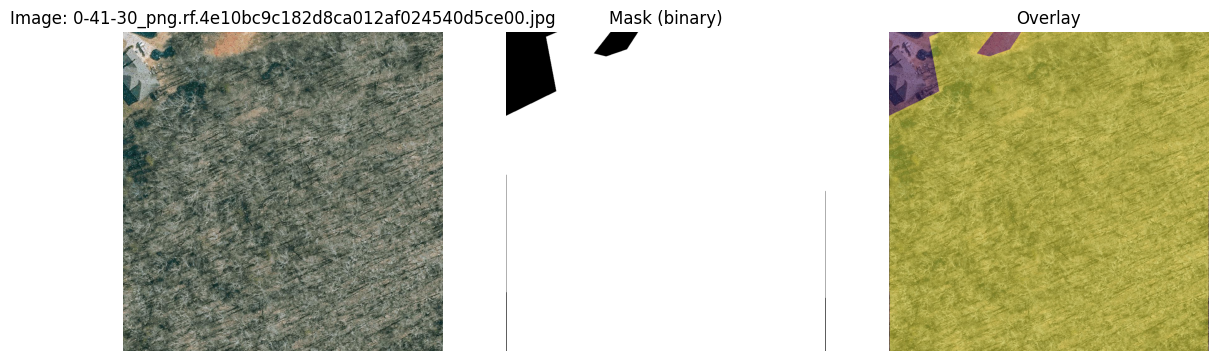

In [ ]:
import random
from pathlib import Path
from PIL import Image, ImageDraw
import numpy as np
import matplotlib.pyplot as plt

DATA_DIR = Path('/content/vegetation-segmentation-4')
SPLIT = 'train'  # 'train' / 'valid' / 'test'

def yolo_txt_to_mask(img_path, txt_path):
    img = Image.open(img_path).convert("RGB")
    w,h = img.size
    mask = Image.new("L", (w,h), 0)
    draw = ImageDraw.Draw(mask)
    text = txt_path.read_text().strip()
    if not text:
        return mask
    for line in text.splitlines():
        parts = line.strip().split()
        coords = list(map(float, parts[1:]))  # skip class id
        pts = [(coords[i]*w, coords[i+1]*h) for i in range(0, len(coords), 2)]
        if pts:
            draw.polygon(pts, outline=1, fill=1)
    return mask

def load_mask_for_image(img_path, lbl_dir):
    base = img_path.stem
    # prefer image mask files
    for ext in ['.png', '.jpg', '.jpeg', '.bmp', '.tiff']:
        p = lbl_dir/(base+ext)
        if p.exists():
            arr = np.array(Image.open(p))
            if arr.ndim==3:
                arr = arr[:,:,0]
            return (arr>0).astype(np.uint8)
    # fallback: YOLO .txt
    ptxt = lbl_dir/(base + '.txt')
    if ptxt.exists():
        return (np.array(yolo_txt_to_mask(img_path, ptxt))>0).astype(np.uint8)
    # missing label -> empty mask
    w,h = Image.open(img_path).size
    return np.zeros((h,w), dtype=np.uint8)

IMG_DIR = DATA_DIR/SPLIT/'images'
LBL_DIR = DATA_DIR/SPLIT/'labels'
imgs = sorted([p for p in IMG_DIR.iterdir() if p.is_file()])
if not imgs:
    raise SystemExit("No images found. Check DATA_DIR and folder structure.")

i = random.randrange(len(imgs))
img_path = imgs[i]
img = np.array(Image.open(img_path).convert('RGB'))
mask = load_mask_for_image(img_path, LBL_DIR)

plt.figure(figsize=(14,6))
plt.subplot(1,3,1); plt.imshow(img); plt.title(f"Image: {img_path.name}"); plt.axis('off')
plt.subplot(1,3,2); plt.imshow(mask, cmap='gray'); plt.title("Mask (binary)"); plt.axis('off')
plt.subplot(1,3,3); plt.imshow(img); plt.imshow(mask, alpha=0.45); plt.title("Overlay"); plt.axis('off')
plt.show()


Covert .txt -> binary mask PNG

In [ ]:
from pathlib import Path
from PIL import Image, ImageDraw
import numpy as np

DATA_DIR = Path('/content/vegetation-segmentation-4')  # change if needed
SPLITS = ['train', 'valid', 'test']
OVERWRITE = False   # set True to overwrite existing masks

def yolo_txt_to_mask(img_path: Path, txt_path: Path):
    """Return a PIL 'L' mask (0/255) from a YOLO-seg .txt file for the given image."""
    img = Image.open(img_path).convert("RGB")
    w, h = img.size
    mask = Image.new("L", (w, h), 0)
    draw = ImageDraw.Draw(mask)

    text = txt_path.read_text().strip()
    if not text:
        return mask  # empty mask

    for line in text.splitlines():
        parts = line.strip().split()
        if len(parts) < 3:
            # not enough data to form a polygon
            continue
        # YOLO-seg commonly: <class> x1 y1 x2 y2 x3 y3 ...
        # skip first token (class id) and interpret remainder as normalized x,y pairs
        try:
            coords = list(map(float, parts[1:]))
        except:
            # if parsing fails, skip
            continue
        if len(coords) % 2 != 0:
            # odd count -- malformed polygon
            continue
        pts = [(coords[i]*w, coords[i+1]*h) for i in range(0, len(coords), 2)]
        if len(pts) >= 3:
            # draw filled polygon as vegetation (white = 255)
            draw.polygon(pts, outline=255, fill=255)
    return mask

summary = {}

for split in SPLITS:
    img_dir = DATA_DIR/split/'images'
    lbl_dir = DATA_DIR/split/'labels'
    out_mask_dir = DATA_DIR/split/'masks'
    out_mask_dir.mkdir(parents=True, exist_ok=True)

    if not img_dir.exists():
        print(f"[WARN] images folder missing: {img_dir} (skipping {split})")
        summary[split] = {'images':0, 'txts':0, 'masks_created':0, 'skipped':0}
        continue
    if not lbl_dir.exists():
        print(f"[WARN] labels folder missing: {lbl_dir} (skipping {split})")
        summary[split] = {'images':0, 'txts':0, 'masks_created':0, 'skipped':0}
        continue

    images = sorted([p for p in img_dir.iterdir() if p.is_file()])
    txts = sorted([p for p in lbl_dir.glob('*.txt')])
    masks_created = 0
    skipped = 0
    missing_txt = 0

    for img_path in images:
        stem = img_path.stem
        txt_path = lbl_dir / (stem + '.txt')
        out_mask_path = out_mask_dir / (stem + '.png')

        if out_mask_path.exists() and not OVERWRITE:
            skipped += 1
            continue

        if txt_path.exists():
            mask_pil = yolo_txt_to_mask(img_path, txt_path)
            # convert to 0/255 uint8 and save
            mask_pil.save(out_mask_path, format='PNG')
            masks_created += 1
        else:
            # no txt annotation for this image -> create empty mask (optional)
            # If you prefer to not create files for missing labels, comment the two lines below.
            empty_mask = Image.new("L", Image.open(img_path).size, 0)
            empty_mask.save(out_mask_path, format='PNG')
            missing_txt += 1

    summary[split] = {
        'images': len(images),
        'txts': len(txts),
        'masks_created': masks_created,
        'skipped': skipped,
        'missing_txt_files': missing_txt
    }
    print(f"[{split}] images={len(images)}, .txt files={len(txts)}, masks_created={masks_created}, skipped(existing)={skipped}, missing_txt={missing_txt}")

print("\nConversion summary (per split):")
for s,v in summary.items():
    print(s, v)

print("\nDone. Masks saved to:")
for split in SPLITS:
    print("-", DATA_DIR/split/'masks')


[train] images=945, .txt files=945, masks_created=945, skipped(existing)=0, missing_txt=0
[valid] images=83, .txt files=83, masks_created=83, skipped(existing)=0, missing_txt=0
[test] images=40, .txt files=40, masks_created=40, skipped(existing)=0, missing_txt=0

Conversion summary (per split):
train {'images': 945, 'txts': 945, 'masks_created': 945, 'skipped': 0, 'missing_txt_files': 0}
valid {'images': 83, 'txts': 83, 'masks_created': 83, 'skipped': 0, 'missing_txt_files': 0}
test {'images': 40, 'txts': 40, 'masks_created': 40, 'skipped': 0, 'missing_txt_files': 0}

Done. Masks saved to:
- /content/vegetation-segmentation-4/train/masks
- /content/vegetation-segmentation-4/valid/masks
- /content/vegetation-segmentation-4/test/masks


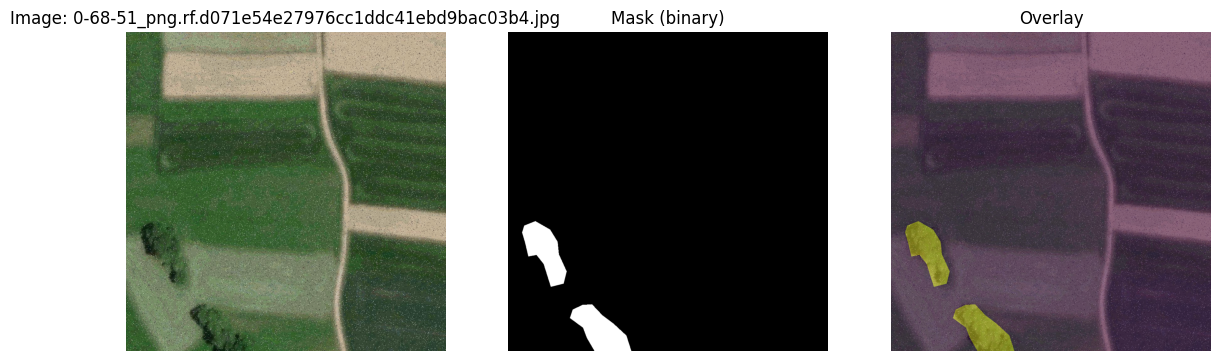

In [ ]:
import random
from pathlib import Path
from PIL import Image, ImageDraw
import numpy as np
import matplotlib.pyplot as plt

DATA_DIR = Path('/content/vegetation-segmentation-4')  # <- change if needed
SPLIT = 'train'  # 'train' / 'valid' / 'test'

def yolo_txt_to_mask(img_path, txt_path):
    img = Image.open(img_path).convert("RGB")
    w,h = img.size
    mask = Image.new("L", (w,h), 0)
    draw = ImageDraw.Draw(mask)
    text = txt_path.read_text().strip()
    if not text:
        return mask
    for line in text.splitlines():
        parts = line.strip().split()
        coords = list(map(float, parts[1:]))  # skip class id
        pts = [(coords[i]*w, coords[i+1]*h) for i in range(0, len(coords), 2)]
        if pts:
            draw.polygon(pts, outline=1, fill=1)
    return mask

def load_mask_for_image(img_path, lbl_dir):
    base = img_path.stem
    # prefer image mask files
    for ext in ['.png', '.jpg', '.jpeg', '.bmp', '.tiff']:
        p = lbl_dir/(base+ext)
        if p.exists():
            arr = np.array(Image.open(p))
            if arr.ndim==3:
                arr = arr[:,:,0]
            return (arr>0).astype(np.uint8)
    # fallback: YOLO .txt
    ptxt = lbl_dir/(base + '.txt')
    if ptxt.exists():
        return (np.array(yolo_txt_to_mask(img_path, ptxt))>0).astype(np.uint8)
    # missing label -> empty mask
    w,h = Image.open(img_path).size
    return np.zeros((h,w), dtype=np.uint8)

IMG_DIR = DATA_DIR/SPLIT/'images'
LBL_DIR = DATA_DIR/SPLIT/'labels'
imgs = sorted([p for p in IMG_DIR.iterdir() if p.is_file()])
if not imgs:
    raise SystemExit("No images found. Check DATA_DIR and folder structure.")

i = random.randrange(len(imgs))
img_path = imgs[i]
img = np.array(Image.open(img_path).convert('RGB'))
mask = load_mask_for_image(img_path, LBL_DIR)

plt.figure(figsize=(14,6))
plt.subplot(1,3,1); plt.imshow(img); plt.title(f"Image: {img_path.name}"); plt.axis('off')
plt.subplot(1,3,2); plt.imshow(mask, cmap='gray'); plt.title("Mask (binary)"); plt.axis('off')
plt.subplot(1,3,3); plt.imshow(img); plt.imshow(mask, alpha=0.45); plt.title("Overlay"); plt.axis('off')
plt.show()


=== DATA CLEANLINESS REPORT ===


--- Checking TRAIN ---
✔ All images have masks
✔ All masks have images
✔ No corrupted files found
✔ All image-mask sizes match
✔ Masks contain only 0 and 255 values
⚠ Empty masks found: ['0-1-19_png.rf.02da791401b3e45bbd2d1fc8e32c96d8.png', '0-1-19_png.rf.4f998264178587902c3a10da8116cdd2.png', '0-1-19_png.rf.a14b70ab7c7e55a73e4511d869f67f62.png', '0-10-47_png.rf.6e64726bce9c25f762627a83871e78c7.png', '0-10-47_png.rf.98b3b4a89713c8e83b23ed3a95a30dc3.png', '0-10-47_png.rf.acd8d5a4237dcb53674db132b6970157.png', '0-13-58_png.rf.2531df3cf5ccf8837941d81d96d4eca5.png', '0-13-58_png.rf.265f41cd185db799e8694047989110a3.png', '0-13-58_png.rf.dd9d0b09d9b82762acb2e7f29d97d531.png', '0-13-5_png.rf.0f78a15fd3e819593a7d7477904f5006.png'] ... (showing first 10)

Showing sample overlay:


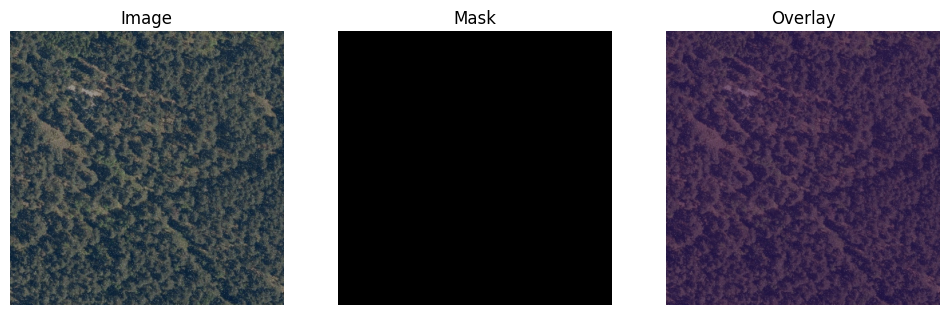


--- Checking VALID ---
✔ All images have masks
✔ All masks have images
✔ No corrupted files found
✔ All image-mask sizes match
✔ Masks contain only 0 and 255 values
⚠ Empty masks found: ['0-22-56_png.rf.8bf43a71796990d696d7ca5382d6a0bd.png', '0-25-27_png.rf.2e12b8648b4b795b1429435fa826309a.png', '0-4-45_png.rf.eb18e36d25649ee3e58a1c6ce83b591f.png', '0-42-49_png.rf.fc5444578c316c4f2c0a5de5d7ef238b.png', '0-43-31_png.rf.972b6b724526bde41727b82e0141777a.png', '0-56-47_png.rf.06449163ae892decb6b5ca9eaa3cca24.png', '0-65-25_png.rf.70e025f2068e6c4c00fbe0e52637a3f7.png', '0-69-26_png.rf.7a4091ba2fdb27b053f027c31f392522.png', '0-8-45_png.rf.4cc20587b08f5d7a0c5c93ee2e361328.png', '0-82-8_png.rf.2ff2845287fdbfa96011676314d81211.png'] ... (showing first 10)

Showing sample overlay:


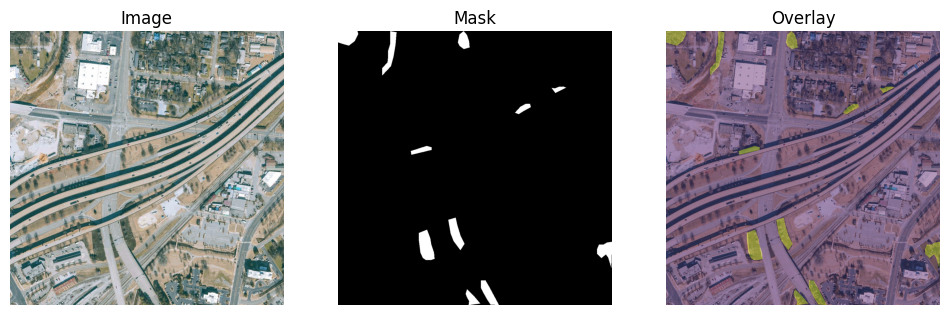


--- Checking TEST ---
✔ All images have masks
✔ All masks have images
✔ No corrupted files found
✔ All image-mask sizes match
✔ Masks contain only 0 and 255 values
⚠ Empty masks found: ['0-59-45_png.rf.be29100b779721b2adf81044c2a61a01.png', '0-70-25_png.rf.59d937be122cecdef46f845388b687ac.png', '0-80-59_png.rf.28d597dced79a7dc09fd4f93c909a506.png', '1-12-26_png.rf.759e05fc774593270341462170c0d534.png', '1-33-13_png.rf.45d6f3fa4b3cb6f7b42eaa83bdc520c0.png'] ... (showing first 10)

Showing sample overlay:


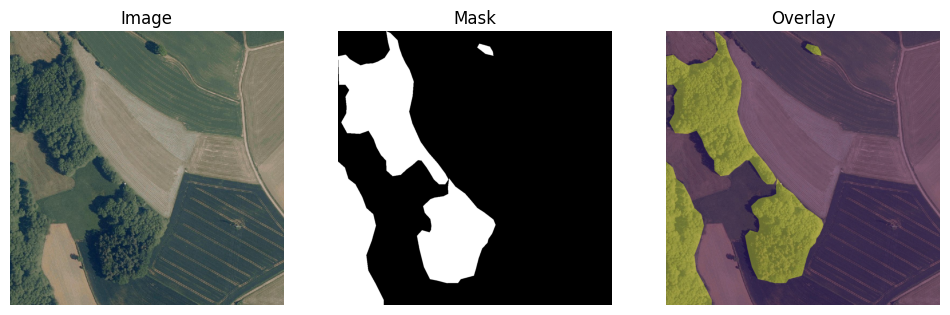


=== CLEANING CHECK COMPLETED ===


In [ ]:
# VERIFY_DATASET_CLEAN.py

from pathlib import Path
from PIL import Image
import numpy as np
import random
import matplotlib.pyplot as plt

DATA_DIR = Path('/content/vegetation-segmentation-4')
SPLITS = ['train', 'valid', 'test']

def is_image_ok(path):
    try:
        Image.open(path).verify()
        return True
    except:
        return False

def visualize_sample(img_path, mask_path):
    img = np.array(Image.open(img_path).convert("RGB"))
    mask = np.array(Image.open(mask_path).convert("L"))

    plt.figure(figsize=(12,5))
    plt.subplot(1,3,1); plt.imshow(img); plt.title("Image"); plt.axis("off")
    plt.subplot(1,3,2); plt.imshow(mask, cmap='gray'); plt.title("Mask"); plt.axis("off")
    plt.subplot(1,3,3); plt.imshow(img); plt.imshow(mask, alpha=0.4); plt.title("Overlay"); plt.axis("off")
    plt.show()

print("=== DATA CLEANLINESS REPORT ===\n")

for split in SPLITS:
    img_dir = DATA_DIR/split/'images'
    mask_dir = DATA_DIR/split/'masks'

    img_paths = sorted([p for p in img_dir.iterdir() if p.is_file()])
    mask_paths = sorted([p for p in mask_dir.iterdir() if p.is_file()])

    print(f"\n--- Checking {split.upper()} ---")

    # 1. Pair checking
    img_stems = {p.stem for p in img_paths}
    mask_stems = {p.stem for p in mask_paths}
    missing_masks = img_stems - mask_stems
    missing_images = mask_stems - img_stems

    if missing_masks:
        print("❌ Missing masks:", missing_masks)
    else:
        print("✔ All images have masks")

    if missing_images:
        print("❌ Missing images:", missing_images)
    else:
        print("✔ All masks have images")

    # 2. Corrupted checks
    corrupted = []
    for p in img_paths + mask_paths:
        if not is_image_ok(p):
            corrupted.append(p.name)

    if corrupted:
        print("❌ Corrupted files:", corrupted)
    else:
        print("✔ No corrupted files found")

    # 3. Size match checks
    size_errors = []
    for img_p in img_paths:
        mask_p = mask_dir/(img_p.stem + ".png")
        if not mask_p.exists(): continue
        try:
            img = Image.open(img_p)
            mask = Image.open(mask_p)
            if img.size != mask.size:
                size_errors.append(img_p.stem)
        except:
            size_errors.append(img_p.stem)

    if size_errors:
        print("Size mismatch:", size_errors)
    else:
        print("✔ All image-mask sizes match")

    # 4. Check mask pixel values
    invalid_masks = []
    for m in mask_paths:
        mask = np.array(Image.open(m).convert("L"))
        unique_vals = set(np.unique(mask))
        # valid values: {0, 255}
        if not unique_vals.issubset({0, 255}):
            invalid_masks.append((m.name, unique_vals))

    if invalid_masks:
        print(" Masks with invalid pixel values:", invalid_masks)
    else:
        print("✔ Masks contain only 0 and 255 values")

    # 5. Check empty masks (optional)
    empty_masks = []
    for m in mask_paths:
        mask = np.array(Image.open(m).convert("L"))
        if mask.max() == 0:
            empty_masks.append(m.name)

    if empty_masks:
        print("⚠ Empty masks found:", empty_masks[:10], "... (showing first 10)")
    else:
        print("✔ No empty masks")

    # 6. Preview sample
    sample_img = random.choice(img_paths)
    sample_mask = mask_dir/(sample_img.stem + ".png")
    print("\nShowing sample overlay:")
    visualize_sample(sample_img, sample_mask)

print("\n=== CLEANING CHECK COMPLETED ===")


In [ ]:
from pathlib import Path
import numpy as np
from PIL import Image

DATA_DIR = Path('/content/vegetation-segmentation-4')
mask_dir = DATA_DIR/'test'/'masks'

empty_count = 0
total = 0

for m in mask_dir.iterdir():
    if m.is_file():
        total += 1
        mask = np.array(Image.open(m).convert("L"))
        if mask.max() == 0:
            empty_count += 1

print("Total test masks:", total)
print("Empty test masks:", empty_count)
print("Percentage empty:", (empty_count/total)*100, "%")


Total test masks: 40
Empty test masks: 5
Percentage empty: 12.5 %


Dataset Cleanliness Report

In [ ]:
from pathlib import Path
import numpy as np
from PIL import Image

DATA_DIR = Path('/content/vegetation-segmentation-4')
SPLITS = ["train", "valid", "test"]

for split in SPLITS:
    mask_dir = DATA_DIR / split / "masks"

    empty_count = 0
    total = 0

    for m in mask_dir.iterdir():
        if m.is_file():
            total += 1
            mask = np.array(Image.open(m).convert("L"))
            if mask.max() == 0:
                empty_count += 1

    print(f"\n--- {split.upper()} ---")
    print("Total masks:", total)
    print("Empty masks:", empty_count)
    print("Percentage empty:", round((empty_count/total)*100, 2), "%")


--- TRAIN ---
Total masks: 945
Empty masks: 117
Percentage empty: 12.38 %

--- VALID ---
Total masks: 83
Empty masks: 10
Percentage empty: 12.05 %

--- TEST ---
Total masks: 40
Empty masks: 5
Percentage empty: 12.5 %


In [ ]:
# =========================================================
# CELL 1 — SEGDATASET FOR SEGFORMER
# =========================================================

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import numpy as np
from pathlib import Path

DATA_DIR = Path('/content/vegetation-segmentation-4')

class VegDataset(Dataset):
    def __init__(self, split):
        self.img_dir = DATA_DIR / split / "images"
        self.mask_dir = DATA_DIR / split / "masks"
        self.images = sorted([p for p in self.img_dir.iterdir() if p.is_file()])

        self.transform_img = transforms.Compose([
            transforms.Resize((512, 512)),
            transforms.ToTensor()
        ])

        self.transform_mask = transforms.Compose([
            transforms.Resize((512, 512)),
        ])

    def __getitem__(self, idx):
        img_path = self.images[idx]
        mask_path = self.mask_dir / (img_path.stem + ".png")

        img = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path).convert("L")

        img = self.transform_img(img)
        mask = self.transform_mask(mask)
        mask = torch.from_numpy(np.array(mask)).long()

        mask = (mask > 127).long()

        return img, mask

    def __len__(self):
        return len(self.images)

train_loader = DataLoader(VegDataset("train"), batch_size=1, shuffle=True)
val_loader   = DataLoader(VegDataset("valid"), batch_size=1, shuffle=False)

print("✔ SegFormer Dataset Loaded")

✔ SegFormer Dataset Loaded


In [ ]:
# =========================================================
# CELL 2 — SEGFORMER B0 MODEL
# =========================================================

!pip install transformers --quiet

from transformers import SegformerForSemanticSegmentation

device = "cuda" if torch.cuda.is_available() else "cpu"

# 2 classes: background + vegetation
model = SegformerForSemanticSegmentation.from_pretrained(
    "nvidia/segformer-b0-finetuned-ade-512-512",
    num_labels=2,
    ignore_mismatched_sizes=True
)

model = model.to(device)

criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=2e-4)

print("✔ SegFormer-B0 Ready on", device)


The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/15.0M [00:00<?, ?B/s]

Some weights of SegformerForSemanticSegmentation were not initialized from the model checkpoint at nvidia/segformer-b0-finetuned-ade-512-512 and are newly initialized because the shapes did not match:
- decode_head.classifier.bias: found shape torch.Size([150]) in the checkpoint and torch.Size([2]) in the model instantiated
- decode_head.classifier.weight: found shape torch.Size([150, 256, 1, 1]) in the checkpoint and torch.Size([2, 256, 1, 1]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✔ SegFormer-B0 Ready on cuda


In [ ]:
# =========================================================
# CELL 3 — TRAIN SEGFORMER (FIXED UPSAMPLING)
# =========================================================

import torch.nn.functional as F

def validate():
    model.eval()
    total = 0

    with torch.no_grad():
        for img, mask in val_loader:
            img, mask = img.to(device), mask.to(device)

            out = model(pixel_values=img).logits

            # 🔥 FIX: upsample logits to mask size
            out = F.interpolate(
                out,
                size=mask.shape[-2:],
                mode="bilinear",
                align_corners=False
            )

            loss = criterion(out, mask)
            total += loss.item()

    return total / len(val_loader)

EPOCHS = 15

for epoch in range(EPOCHS):
    model.train()
    running = 0

    for img, mask in train_loader:
        img, mask = img.to(device), mask.to(device)

        out = model(pixel_values=img).logits

        # 🔥 FIX: match logits to mask shape
        out = F.interpolate(
            out,
            size=mask.shape[-2:],
            mode="bilinear",
            align_corners=False
        )

        loss = criterion(out, mask)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running += loss.item()

    val_loss = validate()
    print(f"Epoch {epoch+1}/{EPOCHS} | Train {running:.4f} | Val {val_loss:.4f}")

torch.save(model.state_dict(), "segformer_veg.pth")
print("✔ SegFormer model saved.")

Epoch 1/15 | Train 496.9838 | Val 0.8295
Epoch 2/15 | Train 421.0526 | Val 0.3119
Epoch 3/15 | Train 380.0495 | Val 0.2002
Epoch 4/15 | Train 360.3798 | Val 0.1958
Epoch 5/15 | Train 283.0528 | Val 0.3281
Epoch 6/15 | Train 240.6525 | Val 0.1842
Epoch 7/15 | Train 455.8932 | Val 0.3107
Epoch 8/15 | Train 286.7185 | Val 0.1780
Epoch 9/15 | Train 201.5900 | Val 0.1929
Epoch 10/15 | Train 219.0451 | Val 0.6442
Epoch 11/15 | Train 172.3662 | Val 3.7345
Epoch 12/15 | Train 198.1846 | Val 1.6777
Epoch 13/15 | Train 156.4370 | Val 1.8314
Epoch 14/15 | Train 144.4501 | Val 1.4059
Epoch 15/15 | Train 161.2699 | Val 0.8426
✔ SegFormer model saved.


In [ ]:
# =========================================================
# CELL 4 — METRICS: ACCURACY, IOU, DICE, CONFUSION MATRIX
# =========================================================

import torch
import torch.nn.functional as F
from sklearn.metrics import confusion_matrix
import numpy as np

def evaluate_metrics():
    model.eval()

    total_pixels = 0
    correct_pixels = 0

    intersection = 0
    union = 0

    dice_numerator = 0
    dice_denominator = 0

    all_true = []
    all_pred = []

    with torch.no_grad():
        for img, mask in val_loader:
            img = img.to(device)
            mask = mask.to(device)

            # forward
            out = model(pixel_values=img).logits

            # upsample to mask size
            out = F.interpolate(out, size=mask.shape[-2:], mode="bilinear", align_corners=False)

            # prediction = argmax over channels
            pred = torch.argmax(out, dim=1)

            # -------- Pixel Accuracy ----------
            total_pixels += mask.numel()
            correct_pixels += (pred == mask).sum().item()

            # -------- IoU ----------
            intersection += torch.logical_and(pred == 1, mask == 1).sum().item()
            union += torch.logical_or(pred == 1, mask == 1).sum().item()

            # -------- Dice ----------
            dice_numerator += 2 * (pred * mask).sum().item()
            dice_denominator += (pred + mask).sum().item()

            # -------- Confusion Matrix ----------
            all_true.extend(mask.cpu().numpy().reshape(-1))
            all_pred.extend(pred.cpu().numpy().reshape(-1))

    pixel_accuracy = correct_pixels / total_pixels
    iou = intersection / (union + 1e-7)
    dice = dice_numerator / (dice_denominator + 1e-7)

    cm = confusion_matrix(all_true, all_pred)

    return pixel_accuracy, iou, dice, cm


acc, iou, dice, cm = evaluate_metrics()

print("Pixel Accuracy :", acc)
print("IoU            :", iou)
print("Dice Score     :", dice)
print("\nConfusion Matrix:")
print(cm)

Pixel Accuracy : 0.6618960277143732
IoU            : 0.5748940232750321
Dice Score     : 0.7300732808414948

Confusion Matrix:
[[4452973 7207287]
 [ 149163 9948529]]


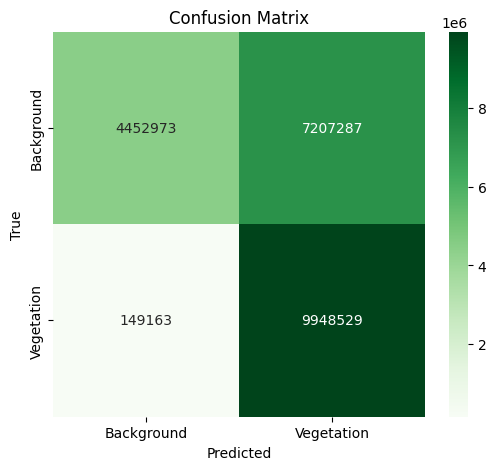

In [ ]:
# =========================================================
# CELL 5 — VISUAL CONFUSION MATRIX (PLOT)
# =========================================================

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import torch.nn.functional as F
import numpy as np

def compute_confusion_matrix():
    model.eval()
    all_true = []
    all_pred = []

    with torch.no_grad():
        for img, mask in val_loader:
            img = img.to(device)
            mask = mask.to(device)

            out = model(pixel_values=img).logits

            # upsample logits
            out = F.interpolate(out, size=mask.shape[-2:], mode="bilinear", align_corners=False)

            pred = torch.argmax(out, dim=1)

            all_true.extend(mask.cpu().numpy().reshape(-1))
            all_pred.extend(pred.cpu().numpy().reshape(-1))

    cm = confusion_matrix(all_true, all_pred)
    return cm

# compute matrix
cm = compute_confusion_matrix()

# plot
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=["Background", "Vegetation"],
            yticklabels=["Background", "Vegetation"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

Some weights of SegformerForSemanticSegmentation were not initialized from the model checkpoint at nvidia/segformer-b0-finetuned-ade-512-512 and are newly initialized because the shapes did not match:
- decode_head.classifier.bias: found shape torch.Size([150]) in the checkpoint and torch.Size([2]) in the model instantiated
- decode_head.classifier.weight: found shape torch.Size([150, 256, 1, 1]) in the checkpoint and torch.Size([2, 256, 1, 1]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Saving vege1.jpg to vege1.jpg
Uploaded: vege1.jpg

======= AREA RESULTS =======
Total Pixels:      262144
Vegetation Pixels: 262144
Non-Vegetation:    0

Vegetation Area:   100.00%
Non-Vegetation:    0.00%



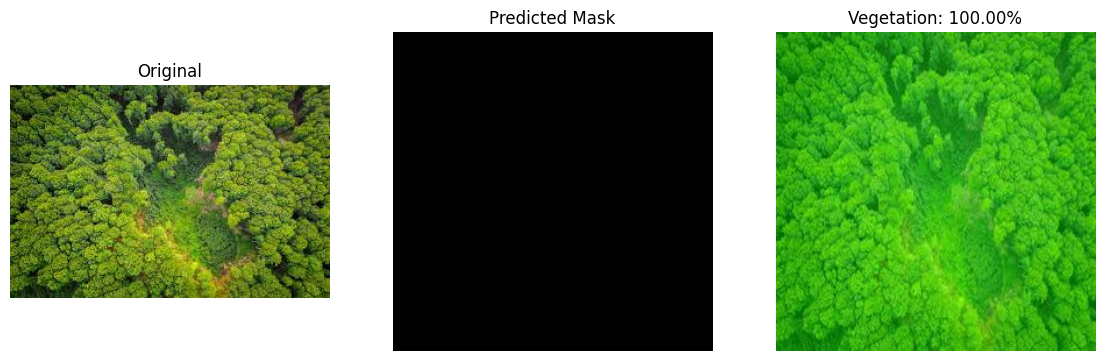

In [ ]:
# =========================================================
# ONE-CELL: UPLOAD → PREDICT → VISUALIZE → AREA PERCENTAGE
# =========================================================

import torch
import torch.nn.functional as F
from transformers import SegformerForSemanticSegmentation
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from torchvision import transforms
from google.colab import files

device = "cuda" if torch.cuda.is_available() else "cpu"

# ---- Load trained model ----
model = SegformerForSemanticSegmentation.from_pretrained(
    "nvidia/segformer-b0-finetuned-ade-512-512",
    num_labels=2,
    ignore_mismatched_sizes=True
)
model.load_state_dict(torch.load("segformer_veg.pth", map_location=device))
model.to(device)
model.eval()

# ---- Upload image ----
uploaded = files.upload()
new_image_path = list(uploaded.keys())[0]
print("Uploaded:", new_image_path)

# ---- Preprocess ----
transform_img = transforms.Compose([
    transforms.Resize((512, 512)),
    transforms.ToTensor()
])

def predict_image(path):
    img = Image.open(path).convert("RGB")
    img_tensor = transform_img(img).unsqueeze(0).to(device)

    with torch.no_grad():
        out = model(pixel_values=img_tensor).logits

        # Upsample logits to 512x512
        out = F.interpolate(out, size=(512, 512), mode="bilinear", align_corners=False)

        pred_mask = torch.argmax(out, dim=1).squeeze().cpu().numpy()

    return img, pred_mask

# ---- Predict ----
img, pred_mask = predict_image(new_image_path)

# ------------ AREA CALCULATIONS ------------
total_pixels = pred_mask.size
veg_pixels = np.sum(pred_mask == 1)
nonveg_pixels = np.sum(pred_mask == 0)

veg_percent = (veg_pixels / total_pixels) * 100
nonveg_percent = (nonveg_pixels / total_pixels) * 100

print("\n======= AREA RESULTS =======")
print(f"Total Pixels:      {total_pixels}")
print(f"Vegetation Pixels: {veg_pixels}")
print(f"Non-Vegetation:    {nonveg_pixels}")
print(f"\nVegetation Area:   {veg_percent:.2f}%")
print(f"Non-Vegetation:    {nonveg_percent:.2f}%")
print("============================\n")

# ---- Create overlay ----
color_mask = np.zeros((512, 512, 3), dtype=np.uint8)
color_mask[pred_mask == 1] = [0, 255, 0]  # green vegetation

overlay = Image.blend(img.resize((512, 512)), Image.fromarray(color_mask), alpha=0.4)

# ---- Show result ----
plt.figure(figsize=(14,5))
plt.subplot(1,3,1); plt.imshow(img); plt.title("Original"); plt.axis("off")
plt.subplot(1,3,2); plt.imshow(pred_mask, cmap="gray"); plt.title("Predicted Mask"); plt.axis("off")
plt.subplot(1,3,3); plt.imshow(overlay); plt.title(f"Vegetation: {veg_percent:.2f}%"); plt.axis("off")
plt.show()

In [ ]:
# ensure model is on CPU before saving (safer for deployment)
model_cpu = model.to("cpu")
torch.save(model_cpu.state_dict(), "segformer_veg.pth")


In [ ]:
from google.colab import files
files.download("segformer_veg.pth")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>